# **MOVIE RATING PREDICTION**

# **OVERVIEW:**

This project aims to predict movie ratings based on features such as genre, director, actors, duration, year, and votes using Machine Learning techniques.


# **Loading the Dataset**

In [ ]:
import pandas as pd

df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

# **Understanding Dataset Structure**

In [ ]:
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

Shape of dataset: (15509, 10)

Column Names:
Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


# **Checking Missing Values**

In [ ]:
print(df.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


# **Removing Missing Target Values**

In [ ]:
df = df.dropna(subset=['Rating'])

print(df.isnull().sum())

print("\nNew Shape:", df.shape)

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

New Shape: (7919, 10)


# **Handling Remaining Missing Values**

In [ ]:
df['Duration'] = df['Duration'].fillna(df['Duration'].mode()[0])

df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])

df['Director'] = df['Director'].fillna(df['Director'].mode()[0])

df['Actor 1'] = df['Actor 1'].fillna(df['Actor 1'].mode()[0])

df['Actor 2'] = df['Actor 2'].fillna(df['Actor 2'].mode()[0])

df['Actor 3'] = df['Actor 3'].fillna(df['Actor 3'].mode()[0])

print(df.isnull().sum())

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


# **Data Cleaning and Type Conversion**

In [ ]:
df['Year'] = df['Year'].str.extract('(\d+)')

df['Year'] = df['Year'].astype(int)

df['Duration'] = df['Duration'].str.replace(' min', '')

df['Duration'] = df['Duration'].astype(int)

df['Votes'] = df['Votes'].str.replace(',', '')

df['Votes'] = df['Votes'].astype(int)

print(df.dtypes)

Name         object
Year          int64
Duration      int64
Genre        object
Rating      float64
Votes         int64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3435/3701296793.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d+)')


# **Encoding Categorical Features**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

df['Director'] = le.fit_transform(df['Director'])

df['Actor 1'] = le.fit_transform(df['Actor 1'])

df['Actor 2'] = le.fit_transform(df['Actor 2'])

df['Actor 3'] = le.fit_transform(df['Actor 3'])

print(df.head())

                                 Name  Year  Duration  Genre  Rating  Votes  \
1  #Gadhvi (He thought he was Gandhi)  2019       109    268     7.0      8   
3                             #Yaaram  2019       110    207     4.4     35   
5                ...Aur Pyaar Ho Gaya  1997       147    177     4.7    827   
6                           ...Yahaan  2005       142    331     7.4   1086   
8                  ?: A Question Mark  2012        82    367     5.6    326   

   Director  Actor 1  Actor 2  Actor 3  
1       811     1782     2814      377  
3      1749     1589      890     2572  
5      2005      508       85     2449  
6      2643      931     1388     3029  
8       174     2520     1461     1205  


# **Feature Selection**

In [ ]:
X = df[['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]

y = df['Rating']

print(X.head())

print("\nTarget:\n", y.head())

   Year  Duration  Votes  Genre  Director  Actor 1  Actor 2  Actor 3
1  2019       109      8    268       811     1782     2814      377
3  2019       110     35    207      1749     1589      890     2572
5  1997       147    827    177      2005      508       85     2449
6  2005       142   1086    331      2643      931     1388     3029
8  2012        82    326    367       174     2520     1461     1205

Target:
 1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


# **Training and Testing Sets**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (6335, 8)
Testing Data Shape: (1584, 8)


# **Training the Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


# **Model Prediction and Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("Predicted Ratings:\n", y_pred[:5])

print("\nActual Ratings:\n", y_test[:5].values)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Predicted Ratings:
 [6.0348698  5.43328865 5.19041366 5.7638264  5.76311861]

Actual Ratings:
 [3.3 5.3 5.7 7.2 3.5]

Mean Absolute Error: 1.0378633700813438
Mean Squared Error: 1.695355623051148
R2 Score: 0.08809937105544186


# **MODEL VISUALIZATION**

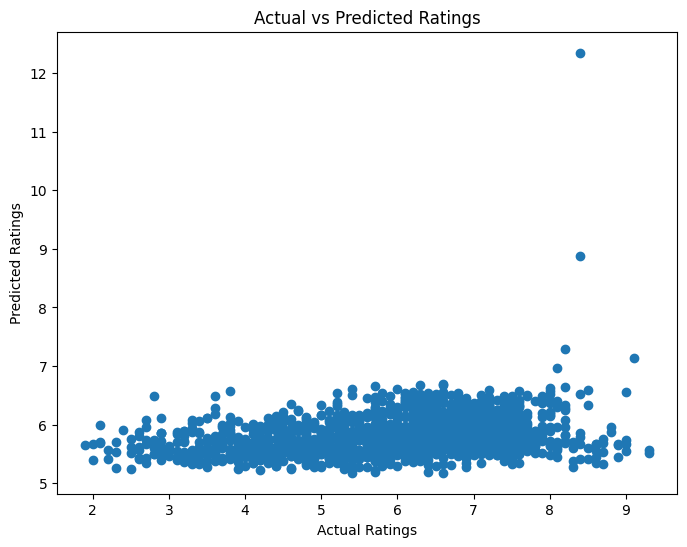

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

# **COMPARING THE MODELS**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# R2 Scores
print("Linear Regression R2 Score:", r2_score(y_test, lr_pred))

print("Decision Tree R2 Score:", r2_score(y_test, dt_pred))

print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Linear Regression R2 Score: 0.08809937105544186
Decision Tree R2 Score: -0.3321398959123041
Random Forest R2 Score: 0.3464027125178426


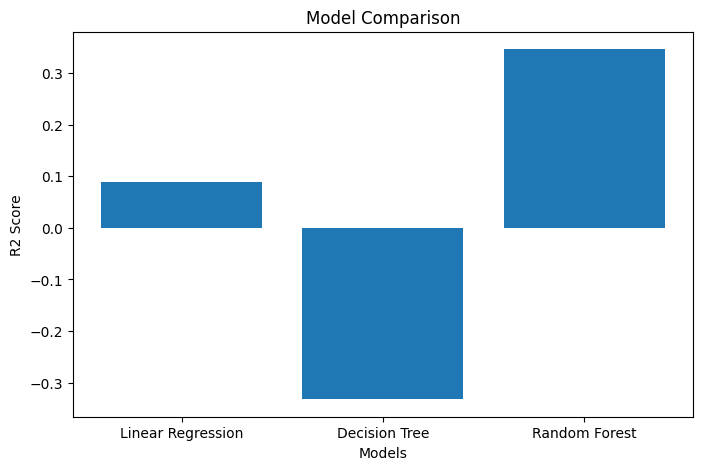

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [0.088, -0.332, 0.346]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

# **FEATURE IMPORTANCE**

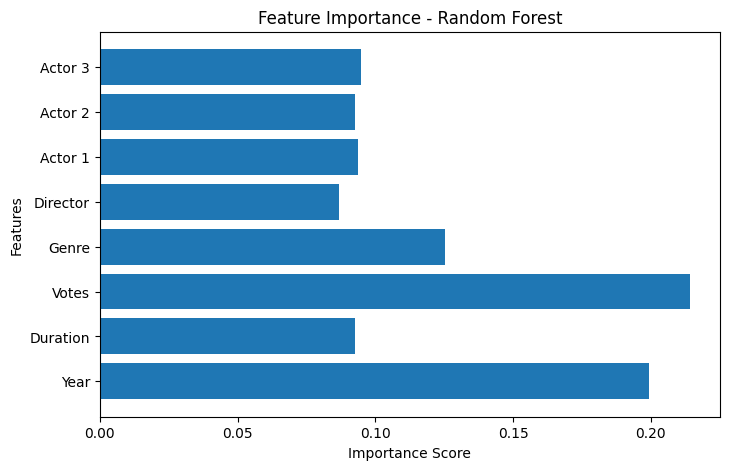

In [ ]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Feature Importance - Random Forest")

plt.show()

# **Custom Movie Rating Prediction**

In [ ]:
sample_movie = pd.DataFrame({
    'Year': [2023],
    'Duration': [120],
    'Votes': [5000],
    'Genre': [200],
    'Director': [1000],
    'Actor 1': [1500],
    'Actor 2': [1200],
    'Actor 3': [900]
})

predicted_rating = rf.predict(sample_movie)

print("Predicted Movie Rating:", predicted_rating[0])

Predicted Movie Rating: 5.690000000000001


**MODEL SAVING**

In [ ]:
import joblib

joblib.dump(rf, 'movie_rating_prediction_model.pkl')

print("Model Saved Successfully")

# **CONCLUSION**

The Movie Rating Prediction project was successfully developed using Machine Learning techniques on the IMDb Movies dataset. The project involved data preprocessing, handling missing values, feature encoding, exploratory data analysis, model training, evaluation, and prediction.

Multiple machine learning models including Linear Regression, Decision Tree Regressor, and Random Forest Regressor were implemented and compared using the R² Score metric. Among all models, the Random Forest Regressor achieved the best performance and produced more accurate movie rating predictions.

This project provided practical experience in machine learning workflow, regression analysis, data preprocessing, feature engineering, visualization, and model evaluation techniques.

# **KEY INSIGHTS**

* The IMDb movie dataset contained several missing values which were successfully handled during preprocessing.
* Categorical features such as Genre, Director, and Actor names were converted into numerical form using Label Encoding.
* Random Forest Regressor outperformed Linear Regression and Decision Tree models in predicting movie ratings.
* Feature Importance Analysis showed that the number of Votes had the highest influence on movie ratings.
* Visualization techniques helped in understanding model performance and prediction patterns.
* The project successfully demonstrated how machine learning can be used to estimate movie ratings based on historical movie data.
